¡Dataset cargado con éxito desde: /home/juanjml/Escritorio/PruebaLatex/ai_student_impact_dataset (1).csv!
Dimensiones iniciales: (50000, 16)

Fase 3 Completada. Dataset definitivo exportado como 'Dataset_Final_Modelado_AI_Impact.csv'

[Entrenando] Iniciando GridSearch para Random Forest...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV] END .max_depth=10, min_samples_split=5, n_estimators=50; total time=   0.1s
[CV] END .max_depth=10, min_samples_split=5, n_estimators=50; total time=   0.1s
[CV] END .max_depth=10, min_samples_split=5, n_estimators=50; total time=   0.1s
[CV] END max_depth=10, min_samples_split=5, n_estimators=100; total time=   0.3s
[CV] END max_depth=10, min_samples_split=5, n_estimators=100; total time=   0.3s
[CV] END max_depth=10, min_samples_split=5, n_estimators=100; total time=   0.3s
[CV] END .max_depth=15, min_samples_split=5, n_estimators=50; total time=   0.2s
[CV] END .max_depth=15, min_samples_split=5, n_estimators=50; total time=   0.2s
[

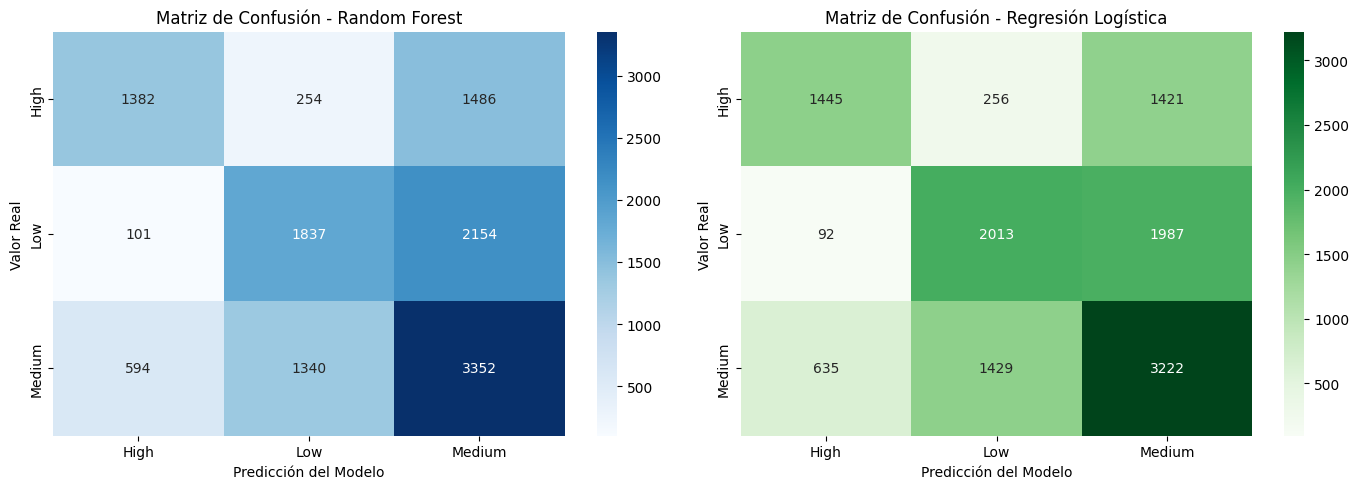

In [4]:
# %% [markdown]
# # PROYECTO FINAL: METODOLOGÍA CRISP-DM
# ## El Impacto de la IA Generativa en el Agotamiento Estudiantil
# **Versión de Alto Rendimiento y Carga Segura**

# %% [code]
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# 1. ENTORNO Y CARGA DE DATOS SEGURA
# =============================================================================
nombre_archivo = 'ai_student_impact_dataset (1).csv'

# Forzar a Python a buscar en la misma carpeta donde está guardado este archivo de código
directorio_actual = os.path.dirname(os.path.abspath(__file__)) if '__file__' in locals() else os.getcwd()
ruta_completa = os.path.join(directorio_actual, nombre_archivo)

if os.path.exists(ruta_completa):
    df = pd.read_csv(ruta_completa)
    print(f"¡Dataset cargado con éxito desde: {ruta_completa}!")
    print(f"Dimensiones iniciales: {df.shape}\n")
else:
    # Intento de carga directa si estás en un Jupyter Notebook puro
    try:
        df = pd.read_csv(nombre_archivo)
        print(f"¡Dataset cargado con éxito en ruta local! Dimensiones: {df.shape}\n")
    except FileNotFoundError:
        df = None
        print("=========================================================================")
        print(f"CRÍTICO: No se encontró el archivo '{nombre_archivo}'")
        print(f"Por favor, asegúrate de mover el archivo .csv a esta carpeta:")
        print(f"👉 {directorio_actual}")
        print("=========================================================================")

# Detener la ejecución limpiamente si no hay datos cargados, evitando el NameError
if df is None:
    raise SystemExit("Ejecución detenida: El dataset no está disponible.")

# =============================================================================
# 2. FASE 3: PREPARACIÓN Y TRANSFORMACIÓN DE DATOS
# =============================================================================
# Eliminación de identificadores administrativos
df_preparado = df.drop(columns=['Student_ID'], errors='ignore')

# Codificación Ordinal para habilidades de Prompt Engineering
mapa_skills = {'Beginner': 0, 'Intermediate': 1, 'Advanced': 2}
df_preparado['Prompt_Engineering_Skill'] = df_preparado['Prompt_Engineering_Skill'].map(mapa_skills)

# Transformación de booleanos a binarios numéricos
df_preparado['Paid_Subscription'] = df_preparado['Paid_Subscription'].astype(int)

# Codificación de la Variable Objetivo (Target: Burnout_Risk_Level)
encoder_target = LabelEncoder()
df_preparado['Burnout_Risk_Level'] = encoder_target.fit_transform(df_preparado['Burnout_Risk_Level'])
clases_reales = encoder_target.classes_  # Guarda los nombres originales (High, Medium, Low)

# Codificación One-Hot para variables categóricas nominales
cols_categoricas = ['Major_Category', 'Year_of_Study', 'Primary_Use_Case', 'Institutional_Policy']
df_final = pd.get_dummies(df_preparado, columns=cols_categoricas, drop_first=True)

# Guardar el dataset final de la Fase 3 como lo exige la consigna
df_final.to_csv('Dataset_Final_Modelado_AI_Impact.csv', index=False)
print("Fase 3 Completada. Dataset definitivo exportado como 'Dataset_Final_Modelado_AI_Impact.csv'")

# =============================================================================
# 3. FASE 4: MODELADO CON AJUSTE DE HIPERPARÁMETROS (OPTIMIZADO)
# =============================================================================
X = df_final.drop(columns=['Burnout_Risk_Level'])
y = df_final['Burnout_Risk_Level']

# Partición del dataset (75% entrenamiento, 25% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# CORRECCIÓN CONCEPTUAL: El escalado de datos SÓLO se aplica a la Regresión Logística.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Modelo A: Random Forest Classifier ---
print("\n[Entrenando] Iniciando GridSearch para Random Forest...")
param_grid_rf = {
    'n_estimators': [50, 100],          
    'max_depth': [10, 15],               
    'min_samples_split': [5]            
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1), param_grid_rf, 
                       cv=StratifiedKFold(n_splits=3), scoring='accuracy', verbose=2)
grid_rf.fit(X_train, y_train)  # Entrenado con datos originales (inmune a escala)
print(f"-> Mejores Hiperparámetros RF: {grid_rf.best_params_}")

# --- Modelo B: Regresión Logística ---
print("\n[Entrenando] Iniciando GridSearch para Regresión Logística...")
param_grid_lr = {
    'C': [0.1, 1, 10],                  
    'solver': ['lbfgs'],                
    'max_iter': [500]                   
}
grid_lr = GridSearchCV(LogisticRegression(random_state=42), param_grid_lr, 
                       cv=StratifiedKFold(n_splits=3), scoring='accuracy', verbose=2)
grid_lr.fit(X_train_scaled, y_train) # Entrenado con datos escalados obligatoriamente
print(f"-> Mejores Hiperparámetros LR: {grid_lr.best_params_}")

# =============================================================================
# 4. FASE 5: EVALUACIÓN PROFUNDA Y COMPARATIVA
# =============================================================================
y_pred_rf = grid_rf.best_estimator_.predict(X_test)          
y_pred_lr = grid_lr.best_estimator_.predict(X_test_scaled)   

print("\n" + "="*50)
print("REPORTE METROLÓGICO Y CAPACIDAD DE COMPRESIÓN")
print("="*50)
print("\n1. MÉTRICAS DETALLADAS - RANDOM FOREST (Datos No Escalados)")
print(classification_report(y_test, y_pred_rf, target_names=clases_reales))

print("\n2. MÉTRICAS DETALLADAS - REGRESIÓN LOGÍSTICA (Datos Escalados)")
print(classification_report(y_test, y_pred_lr, target_names=clases_reales))

kappa_rf = cohen_kappa_score(y_test, y_pred_rf)
kappa_lr = cohen_kappa_score(y_test, y_pred_lr)
print(f"Robustez (Kappa de Cohen) - Random Forest: {kappa_rf:.4f}")
print(f"Robustez (Kappa de Cohen) - Regresión Logística: {kappa_lr:.4f}\n")

cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_lr = confusion_matrix(y_test, y_pred_lr)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=clases_reales, yticklabels=clases_reales, ax=ax[0])
ax[0].set_title('Matriz de Confusión - Random Forest')
ax[0].set_xlabel('Predicción del Modelo')
ax[0].set_ylabel('Valor Real')

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens', xticklabels=clases_reales, yticklabels=clases_reales, ax=ax[1])
ax[1].set_title('Matriz de Confusión - Regresión Logística')
ax[1].set_xlabel('Predicción del Modelo')
ax[1].set_ylabel('Valor Real')

plt.tight_layout()
plt.show()